In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
import statsmodels.api as sm
from scipy.optimize import minimize
from pathlib import Path


In [2]:
class SmartBeta:
    """Smart‑beta portfolio construction supporting multiple weighting schemes.

    Parameters
    ----------
    prices : pd.DataFrame
        Asset price history (rows: dates, columns: tickers).
    scheme : str
        One of {"EW", "RP", "DR", "GMV", "MSR"}.
    rf : float, optional
        Risk‑free rate for Sharpe ratio calculation (annualised, matching the
        frequency of *prices*). Default is 0.
    lb, ub : float, optional
        Lower/upper bounds for individual weights. Defaults are 1 % and 10 %.
    tol : float, optional
        Optimiser tolerance. Default is 1e‑10 (tight but stable with LW shrinkage).
    """

    def __init__(self, prices: pd.DataFrame, scheme: str,
                 rf: float = 0.0, lb: float = 0.01, ub: float = 1,
                 tol: float = 1e-10):
        self.prices = prices.dropna(axis=0, how="any").copy()
        self.scheme = scheme.upper()
        self.rf = rf
        self.lb, self.ub = lb, ub
        self.tol = tol

        # --- Pre‑compute inputs shared by all schemes -----------------------
        self.returns = self.prices.pct_change().dropna()
        # Ledoit–Wolf shrinkage covariance for better stability
        self.cov = LedoitWolf().fit(self.returns).covariance_
        self.mu = self.returns.mean().values
        self.n_assets = self.returns.shape[1]

    # --------------------------------------------------------------------- #
    # Objective functions                                                   #
    # --------------------------------------------------------------------- #
    def _risk_parity(self, w: np.ndarray) -> float:
        port_vol = np.sqrt(w @ self.cov @ w)
        mrc = (self.cov @ w) / port_vol  # marginal contributions
        rc = w * mrc                     # total contributions
        return np.var(rc)                # minimise variance of RC → RP

    def _diversification_ratio(self, w: np.ndarray) -> float:
        asset_vol = np.sqrt(np.diag(self.cov))
        port_vol = np.sqrt(w @ self.cov @ w)
        dr = (w @ asset_vol) / port_vol  # >1 ; maximise
        return -dr                       # minimise negative DR

    def _min_variance(self, w: np.ndarray) -> float:
        return w @ self.cov @ w

    def _neg_sharpe(self, w: np.ndarray) -> float:
        port_mean = self.mu @ w
        port_vol = np.sqrt(w @ self.cov @ w)
        sr = (port_mean - self.rf) / port_vol
        return -sr                       # maximise SR → minimise –SR

    # --------------------------------------------------------------------- #
    # Weight optimiser                                                      #
    # --------------------------------------------------------------------- #
    def optimise(self) -> np.ndarray:
        if self.scheme == "EW":
            return np.repeat(1 / self.n_assets, self.n_assets)

        objective = {
            "RP": self._risk_parity,
            "DR": self._diversification_ratio,
            "GMV": self._min_variance,
            "MSR": self._neg_sharpe,
        }[self.scheme]

        x0 = np.repeat(1 / self.n_assets, self.n_assets)
        bounds = tuple((self.lb, self.ub) for _ in range(self.n_assets))
        cons = ({'type': 'eq', 'fun': lambda w: 1.0 - np.sum(w)},)

        res = minimize(objective, x0, method="SLSQP", bounds=bounds,
                       constraints=cons, tol=self.tol)
        if not res.success:
            raise RuntimeError(f"{self.scheme} optimisation failed: {res.message}")
        return res.x

    # --------------------------------------------------------------------- #
    # Public helpers                                                        #
    # --------------------------------------------------------------------- #
    def weights(self) -> pd.Series:
        """Return optimised weights as a labelled Series."""
        return pd.Series(self.optimise(), index=self.returns.columns, name=self.scheme)

    def portfolio_returns(self) -> pd.Series:
        """Historical portfolio returns using the optimised weights."""
        w = self.optimise()
        return (self.returns @ w).rename(self.scheme)


# ------------------------------------------------------------------------- #
# Utility functions                                                         #
# ------------------------------------------------------------------------- #

def compute_scheme_returns(prices: pd.DataFrame,
                           schemes=("EW", "RP", "DR", "GMV", "MSR"),
                           rf: float = 0.0) -> pd.DataFrame:
    """Convenience wrapper: build every scheme and concatenate their returns."""
    port_rets = [SmartBeta(prices, sch, rf=rf).portfolio_returns() for sch in schemes]
    return pd.concat(port_rets, axis=1)


def pca_factors(factor_prices: pd.DataFrame, n_components: int = 5) -> pd.DataFrame:
    """Simple PCA factor extraction with standardisation (part a)."""
    returns = factor_prices.pct_change().dropna()
    z = StandardScaler().fit_transform(returns)
    pcs = PCA(n_components=n_components).fit_transform(z)
    pc_cols = [f"PC{i+1}" for i in range(n_components)]
    return pd.DataFrame(pcs, index=returns.index, columns=pc_cols)


In [3]:

if __name__ == "__main__":
  
    fp = Path("data.xlsx")

    equity_df = pd.read_excel(fp, sheet_name="equity", index_col=0, parse_dates=[0])
    factor_df = pd.read_excel(fp, sheet_name="factor", index_col=0, parse_dates=[0])

    # ---- Part A: PCs -----------------------------------------------------
    pcs_df = pca_factors(factor_df, n_components=5)

    # ---- Part B: Betas & mimicking portfolio ---------------------------
    equity_rets = equity_df.pct_change().dropna()
    excess = equity_rets.sub(0)  # rf = 0 assumed
    model = sm.OLS(pcs_df, excess).fit()
    betas = model.params
    

    # ---- Part C: Scheme returns ----------------------------------------
    scheme_returns = compute_scheme_returns(equity_df, rf=0)
    
    print(scheme_returns.tail())


                  EW        RP        DR       GMV       MSR
2016-09-30  0.001325  0.001448 -0.006784  0.000109  0.004155
2016-10-31  0.008201  0.007679  0.012181 -0.017735 -0.000303
2016-11-30  0.004646  0.004330  0.007042  0.001773  0.009491
2016-12-30  0.021345  0.024634  0.012940  0.038718 -0.004268
2017-01-31  0.018355  0.016644  0.018356  0.006980  0.038733


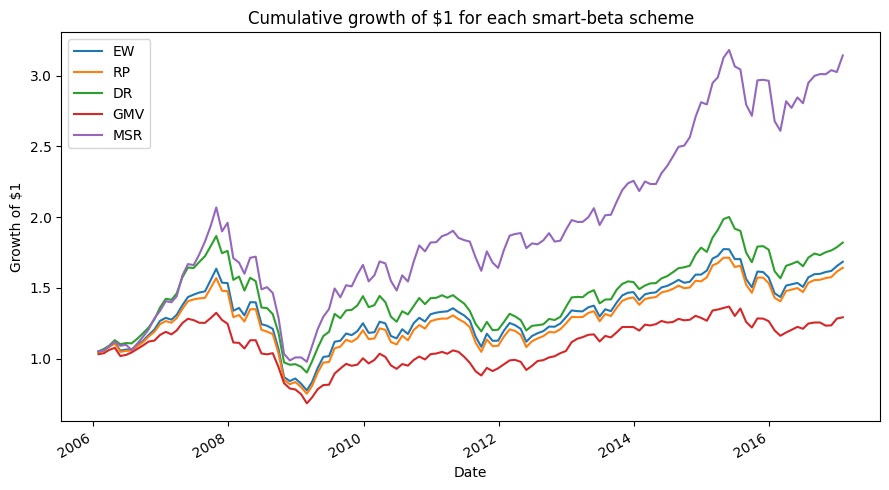

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# Convert the (simple) returns into cumulative growth of 1 unit invested
cumulative = (1 + scheme_returns).cumprod()

# --- Plot -----------------------------------------------------------------
plt.figure(figsize=(9, 5))
cumulative.plot(ax=plt.gca())
plt.title("Cumulative growth of $1 for each smart-beta scheme")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.tight_layout()
plt.show()


In [5]:
pip install ace_tools

Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
import math



# Assume daily data; adjust `trading_days` if your frequency differs
trading_days = 252

# --- Risk metrics ---------------------------------------------------------
annualised_mean = scheme_returns.mean() * trading_days
annualised_vol  = scheme_returns.std()  * np.sqrt(trading_days)
sharpe_ratio    = annualised_mean / annualised_vol

# Compound annual growth rate (geometric return)
cumulative = (1 + scheme_returns).cumprod()
n_years = (cumulative.index[-1] - cumulative.index[0]).days / 365.25
cagr = cumulative.iloc[-1] ** (1 / n_years) - 1

metrics = pd.DataFrame({
    "CAGR": cagr,
    "Annual Mean": annualised_mean,
    "Annual Vol": annualised_vol,
    "Sharpe": sharpe_ratio
})

# Show risk metrics
print(metrics.round(4))


       CAGR  Annual Mean  Annual Vol  Sharpe
EW   0.0486       1.2499      0.7131  1.7529
RP   0.0461       1.1890      0.6967  1.7066
DR   0.0560       1.3832      0.6946  1.9914
GMV  0.0236       0.6511      0.5707  1.1408
MSR  0.1097       2.5033      0.7991  3.1327
